# Reference Values by d repeated faulty syndrome extraction for each round 

Data generation and analysis
+ decoder
    + currently only: mwpm_full_info
    + mwpm with independent decoding for each round still broken due to last measurement 
+ different observables: Z,X
+ different distances
+ different noise levels
+ multiple rounds

analysis: 
+ determine thresholds depended on number of rounds


In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tools.file import write_config, smart_read_folder
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

## Config Defintions and Data Generation

Circuit level noise and syndrome extraction using the standard principle with repeated syndrome extraction in each round to account for measurement errors.

The approach is an upper bound. This decoder has more info, than the independent round decoder for the steane case!!

In [21]:
# TODO: Rerun with those parameters
# General parameter
expected_p_th_log = -2
width = 0.5
noise_rates = [float(x) for x in np.logspace(expected_p_th_log - width , expected_p_th_log + width,dtype=float)]
distances = [3,5,7,9,]
qec_rounds = [1,2,4,6,]#8,10]
order = "0p"
circuit_type = "surface"
noise_model_type = "circ"

# Main parameters
# mwpm
num_shots = 2_000
decoder_type = "mwpm_full_info"

# Z config
observable_Z  = "Z"
init_state_Z = "0"
# X config
observable_X  = "X"
init_state_X = "p"

In [22]:
# Folder names (for writing data to file):
general_name = "md_mr_mp_reference"

In [23]:
# Switches for data generation
regen_data_everything = False 

regen_data_MWPM = False 


In [24]:
# MWPM full info Config (Z)

config_MWPM_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type, 
    },
    "sampling": {
        "num_shots":    num_shots,       # number of shots per configuration
    },
}

# write config to file
config_path = write_config(config_MWPM_Z, general_name, backup=True, sub_name="MWPM_Z")

# Generate ML Data
if regen_data_everything or regen_data_MWPM or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

In [25]:
# MWPM full info Config (X)

config_MWPM_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type, 
    },
    "sampling": {
        "num_shots":    num_shots,     
    },
}

# write config to file
config_path = write_config(config_MWPM_X, general_name, backup=True, sub_name="MWPM_X")

# Generate ML Data
if regen_data_everything or regen_data_MWPM or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

# Analysis 

In [26]:
# Folder paths (reading in data)
# r_folder_path_MWPM_Z = "/home/fu494742/MasterArbeit/code/data/surface/0p/circ/mwpm_full_info/z/md_mr_mp_reference_short"
# r_folder_path_MWPM_X = "/home/fu494742/MasterArbeit/code/data/surface/0p/circ/mwpm_full_info/x/md_mr_mp_reference_short"

r_folder_path_MWPM_Z = "/home/fu494742/MasterArbeit/code/data/surface/0p/circ/mwpm_full_info/z/md_mr_mp_reference"
r_folder_path_MWPM_X = "/home/fu494742/MasterArbeit/code/data/surface/0p/circ/mwpm_full_info/x/md_mr_mp_reference"
per_round = False

In [27]:
def analysis_pipeline(
        folder_path, 
        guess_pth, 
        guess_nu, 
        min_distance: list = None, 
        max_distance: list = None,
        min_noise_rate: list = None,
        max_noise_rate: list = None,
        p_window: float = None,
        plots = True,
        ):

    if p_window != None:
        if min_noise_rate != None or max_noise_rate != None:
            raise UserWarning("Both p_window and min-/max_noise_rate give! Too much restictions!")
        min_noise_rate = np.array(guess_pth) / p_window
        max_noise_rate = np.array(guess_pth) * p_window

    config, data = smart_read_folder(folder_path=folder_path)
    print(data["num_shots"])
    data = data_pre_processing(data)
    data = determine_threshold(
        data,
        guess_nu=guess_nu,
        guess_pth=guess_pth,
        min_distance=min_distance,
        max_distance=max_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
        )
    if per_round:
        data = determine_threshold(
            data,
            guess_nu=guess_nu,
            guess_pth=guess_pth,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            log_error_rate_per_round=True,
            )
    # complete
    if plots:
        data_plot_log_error_rates(data)
        data_plot_fssa_results(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            )
        # around threshold
        data_plot_log_error_rates(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
        )
    return data

### Generate analysis Data

In [28]:
# General fit parameters: 
g_pth_mwpm_Z_ref = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,]
g_pth_mwpm_X_ref = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,] 


g_nu = [1.5] * len(qec_rounds )  # not short and long do not share the same setup!

p_window = 10**(0.15)
min_distance = [5] * len(qec_rounds)

In [29]:
folder_path = r_folder_path_MWPM_Z 
g_pth = g_pth_mwpm_Z_ref

result = analysis_pipeline(
    folder_path = folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_Z= result

80000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.18573935485578
             x: [ 8.874e-03  1.022e+00]
           nit: 65
          nfev: 127
 final_simplex: (array([[ 8.874e-03,  1.022e+00],
                       [ 8.874e-03,  1.022e+00],
                       [ 8.874e-03,  1.022e+00]]), array([ 1.186e+00,  1.186e+00,  1.186e+00]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.2348335722478554
             x: [ 8.627e-03  1.027e+00]
           nit: 47
          nfev: 92
 final_simplex: (array([[ 8.627e-03,  1.027e+00],
                       [ 8.627e-03,  1.027e+00],
                       [ 8.627e-03,  1.027e+00]]), array([ 2.235e+00,  2.235e+00,  2.235e+00]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 4.090176252118108
             x: [ 8.577e-03  1.048e+00]
           nit: 46
    

IndexError: list index out of range

78000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9591373384959296
             x: [ 9.539e-03  1.069e+00]
           nit: 73
          nfev: 134
 final_simplex: (array([[ 9.539e-03,  1.069e+00],
                       [ 9.539e-03,  1.069e+00],
                       [ 9.539e-03,  1.069e+00]]), array([ 9.591e-01,  9.591e-01,  9.591e-01]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.5154350657283433
             x: [ 9.082e-03  1.041e+00]
           nit: 69
          nfev: 128
 final_simplex: (array([[ 9.082e-03,  1.041e+00],
                       [ 9.082e-03,  1.041e+00],
                       [ 9.082e-03,  1.041e+00]]), array([ 2.515e+00,  2.515e+00,  2.515e+00]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3.251665869684703
             x: [ 9.102e-03  1.061e+00]
           nit: 47
 

<Figure size 640x480 with 0 Axes>

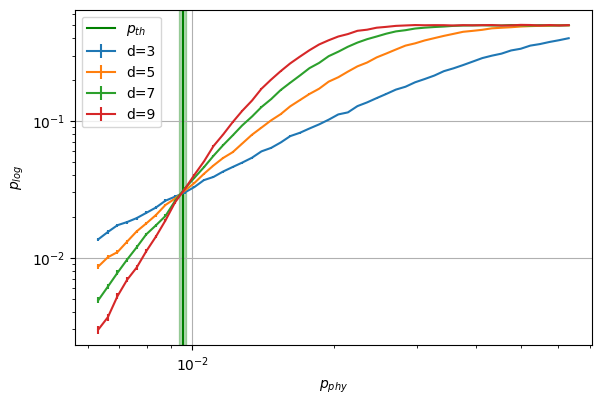

<Figure size 640x480 with 0 Axes>

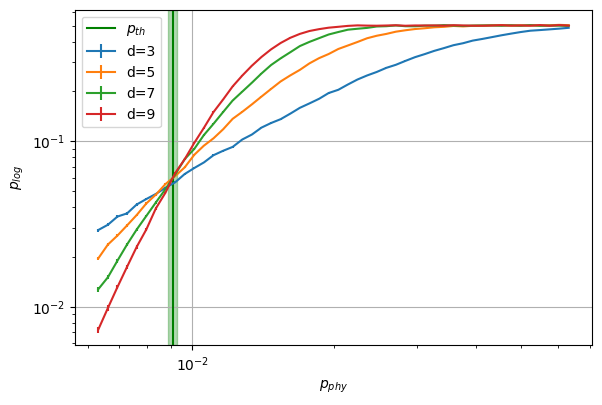

<Figure size 640x480 with 0 Axes>

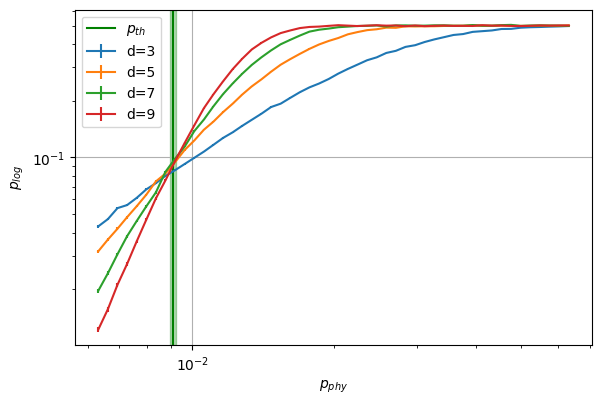

<Figure size 640x480 with 0 Axes>

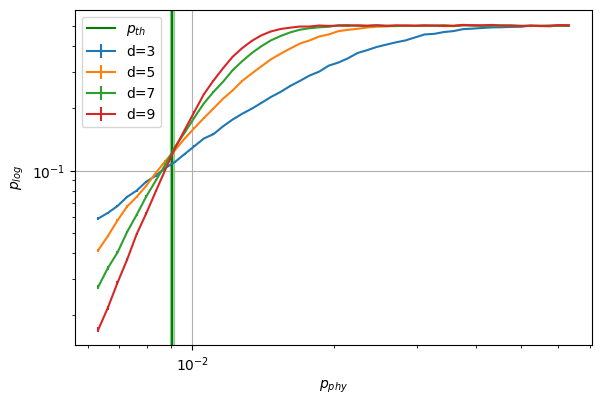

<Figure size 640x480 with 0 Axes>

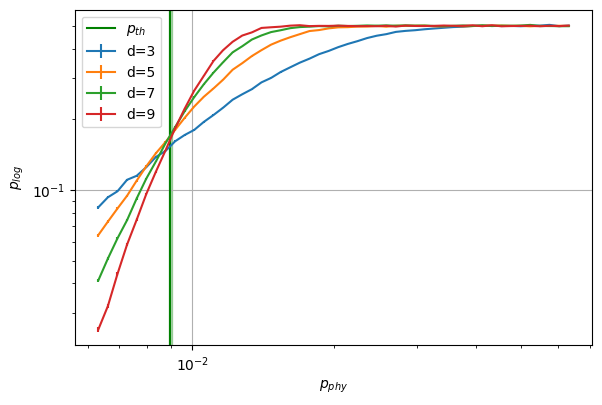

<Figure size 640x480 with 0 Axes>

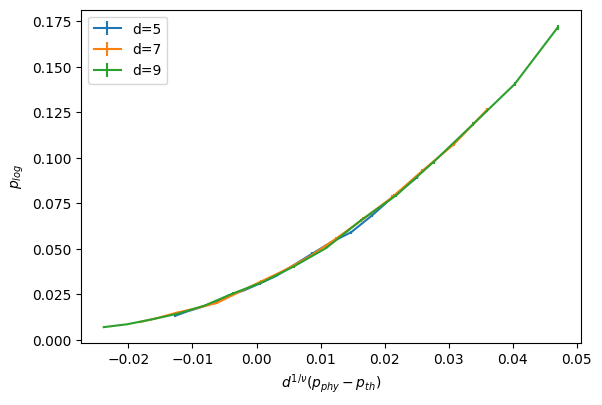

<Figure size 640x480 with 0 Axes>

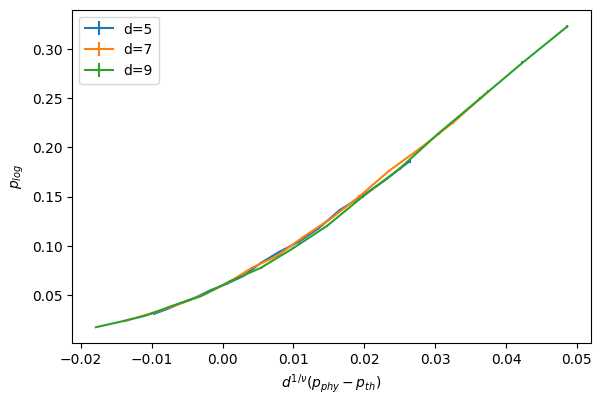

<Figure size 640x480 with 0 Axes>

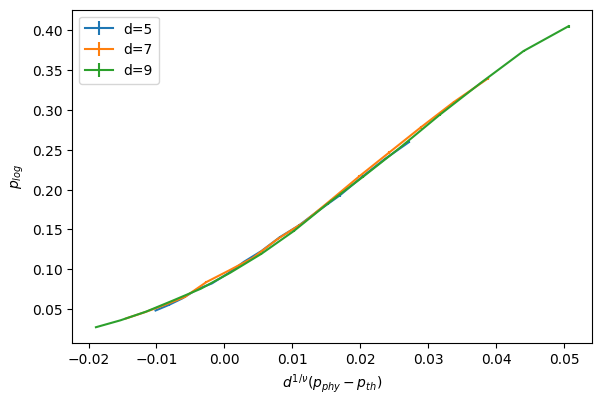

<Figure size 640x480 with 0 Axes>

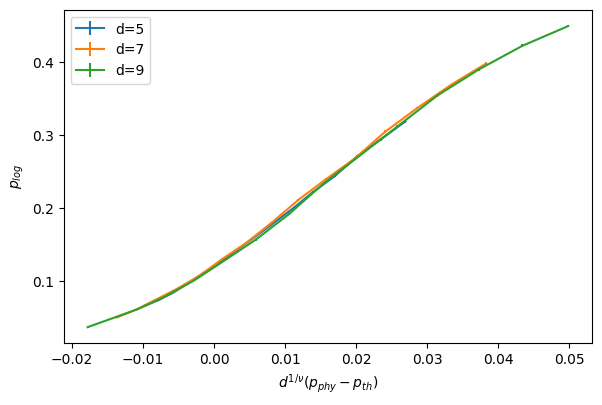

<Figure size 640x480 with 0 Axes>

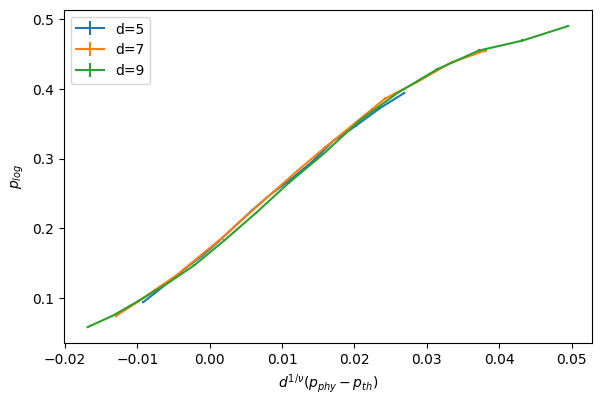

<Figure size 640x480 with 0 Axes>

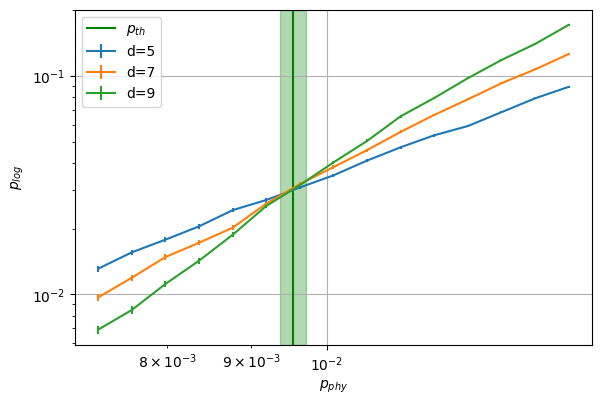

<Figure size 640x480 with 0 Axes>

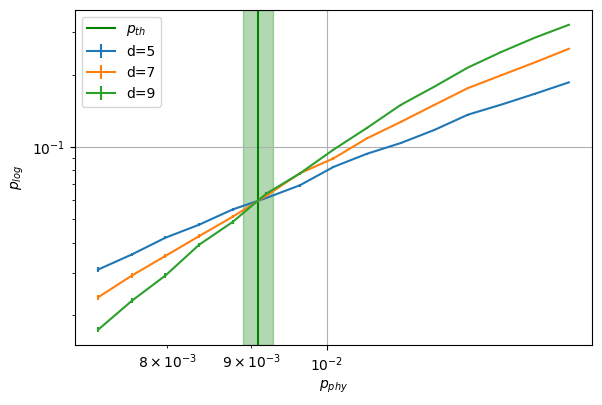

<Figure size 640x480 with 0 Axes>

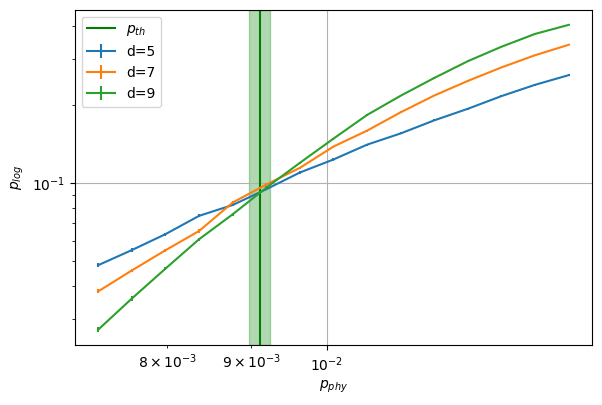

<Figure size 640x480 with 0 Axes>

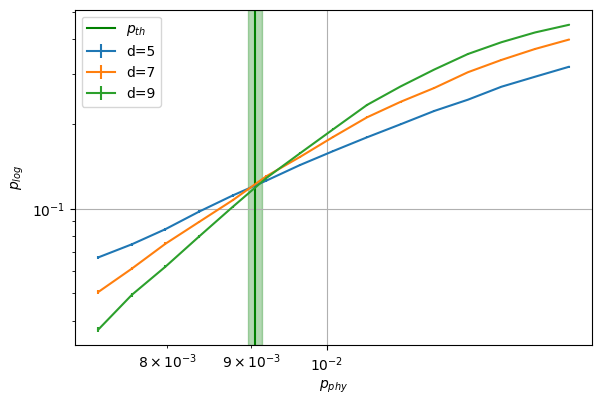

<Figure size 640x480 with 0 Axes>

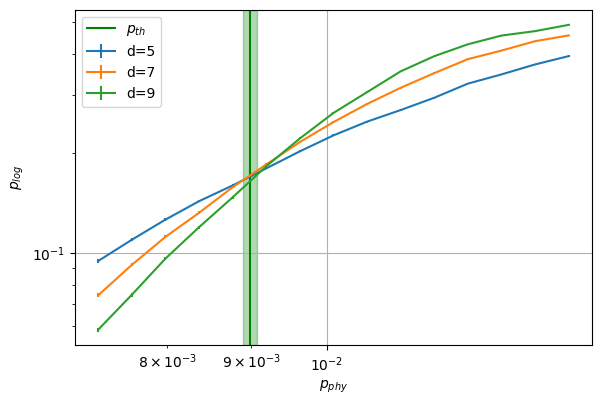

[0.00953926 0.00908168 0.00910247 0.00904498 0.00898305]
[0.9351972  0.96097482 0.94249391 0.95373591 0.96169815]


In [ ]:
folder_path = r_folder_path_MWPM_X 
g_pth = g_pth_mwpm_X_ref 

result = analysis_pipeline(
    folder_path = folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_X = result

In [ ]:
results = [results_MWPM_Z, results_MWPM_X]
names = ["MWPM Z", "MWPM X"]
for i in range(len(results)):
    print(f"{names[i]}: num_shots = {results[i]["num_shots"]/10**3}k")

MWPM Z: num_shots = 2.0k
MWPM X: num_shots = 2.0k


## Results

In [ ]:
from tools.parameter import PATH_TO_IMAGE_FOLDER

In [ ]:
results = [ results_MWPM_Z, results_MWPM_X]
names = [ "MWPM Z", "MWPM X"]

for i in range(len(names)):
    print(f"For {names[i]}: threshold = {results[i]["p_th"][-1]*10**2:.3f} +- {results[i]["err_p_th"][0]*10**2:.3f}") 
    if per_round:
        print(f"For {names[i]}: threshold (p.r.) = {results[i]["p_th_per_round"][-1]*10**2:.3f} +- {results[i]["err_p_th_per_round"][0]*10**2:.3f}") 

For MWPM Z: threshold = 1.995 +- 0.438
For MWPM X: threshold = 1.997 +- 0.390


<Figure size 640x480 with 0 Axes>

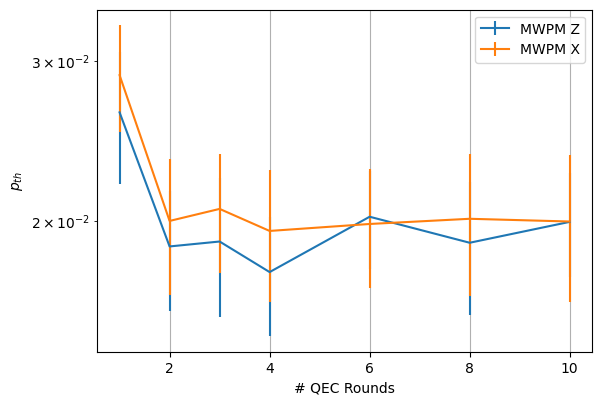

In [ ]:
results = [results_MWPM_Z, results_MWPM_X]
names = ["MWPM Z", "MWPM X"]

plt.figure()
cm = 1/2.54 # to convert inches to cm
plt.subplots(figsize=(15*cm,10*cm),constrained_layout=True)
for i in range(len(results)): 
    p_th = results[i]["p_th"]
    err_p_th = results[i]["err_p_th"]
    plt.errorbar(qec_rounds, p_th, yerr=err_p_th,label=names[i])
plt.xlabel("# QEC Rounds")
plt.ylabel("$p_{th}$")
plt.legend()
plt.yscale("log")
plt.grid()
plt.savefig(PATH_TO_IMAGE_FOLDER+"/"+ "multi_round_all_log"+".pdf") 
plt.show()


<Figure size 640x480 with 0 Axes>

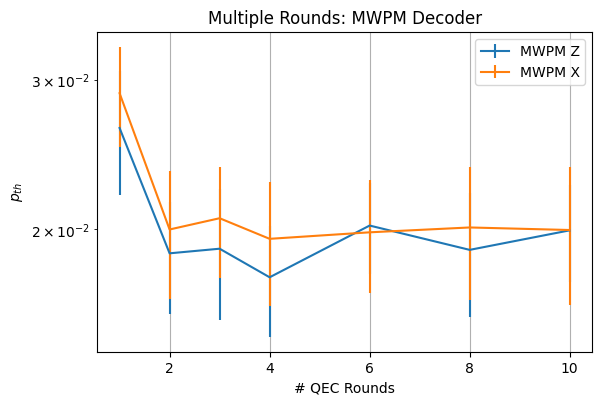

In [ ]:
results = [results_MWPM_Z, results_MWPM_X]
names = ["MWPM Z", "MWPM X"]

plt.figure()
cm = 1/2.54 # to convert inches to cm
plt.subplots(figsize=(15*cm,10*cm),constrained_layout=True)
plt.title("Multiple Rounds: MWPM Decoder")
for i in range(len(results)): 
    p_th = results[i]["p_th"]
    err_p_th = results[i]["err_p_th"]
    plt.errorbar(qec_rounds, p_th, yerr=err_p_th,label=names[i])
plt.xlabel("# QEC Rounds")
plt.ylabel("$p_{th}$")
plt.legend()
plt.yscale("log")
plt.grid()
plt.savefig(PATH_TO_IMAGE_FOLDER+"/"+ "multi_round_MWPM_log"+".pdf") 
plt.show()